# Lab 13

## Section 1: PyTorch 



## Import Torch

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

In [2]:
# pip install torch

### Task 1: GPU/Device Agnostic Code
**Goal:** Write code that runs on CPU, CUDA, or MPS (Mac) automatically.


In [3]:
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f'Using device: {device}')


sample_input = torch.randn(1, 10).to(device)
type(sample_input)

Using device: cpu


torch.Tensor

In [4]:
sample_input

tensor([[-0.7050,  2.7177, -0.5817, -0.5663,  0.3532, -0.4698, -0.5062, -1.7222,
         -0.0335, -0.3624]])

## Section 2: MNIST Project 
Step 1: What is MNIST & Downloading Data

Concept: MNIST is the "Hello World" of Machine Learning. It contains 70,000 images of handwritten digits (0-9).

The Goal: Teach the computer to look at a grid of pixels and say "That is a 7".

The Data: Each image is grayscale and exactly 28×28


In [5]:
from torchvision import datasets
from torchvision.transforms import ToTensor

In [6]:
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

# transform=ToTensor() converts the image (0-255) to a Torch Tensor (0.0-1.0)

100%|██████████| 26.4M/26.4M [00:01<00:00, 18.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 348kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 6.34MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.2MB/s]


In [7]:
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

## Visualizing One Image & Understanding Shapes

In [8]:
len(training_data)

60000

In [9]:
len(test_data)

10000

In [10]:
img, label = training_data[0]

In [11]:
img.shape

torch.Size([1, 28, 28])

In [12]:
img

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
          0.2863, 0.0000, 0.0000, 0.0039, 0.0157, 0.0000,

In [13]:
img.squeeze().shape

torch.Size([28, 28])

## Display one Image in MatplotLib

In [14]:
import matplotlib.pyplot as plt

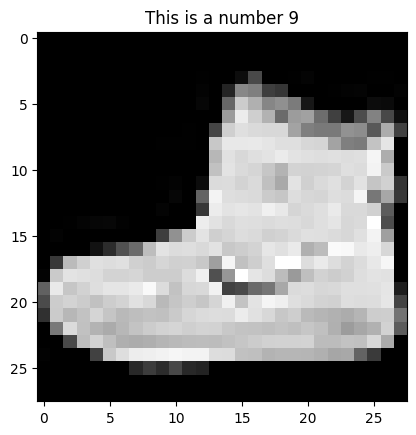

In [15]:
plt.imshow(img.squeeze(), cmap="gray")
plt.title(f"This is a number {label}")
plt.show()

# Calculation for the Input Layer

Concept: We are building a Linear (Feed-Forward) Network,

A Linear Layer consists of neurons in a single vertical line.

Our image is a square grid (28×28).

The Division: We must "cut" the image row by row and stack them into one long line.

The Calculation:

Height×Width=Total Input Features
28×28=784
So, our Input Layer must have 784 neurons.

In [16]:
img, label = training_data[1]

In [17]:
img.squeeze().shape

torch.Size([28, 28])

## The Architecture (1 Input, 1 Hidden, 1 Output
The Concept: We will build the simplest standard network.

Input Layer (784): Receives the pixels.

Hidden Layer (128): The "brain" that learns shapes (loops, lines). We pick 128 because it's enough to learn but not too big.

Output Layer (10): The final decision. We have 10 digits (0-9), so we need 10 output scores.

In [18]:
import torch.nn as nn

class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        
        self.layers = nn.Sequential(
            nn.Linear(784, 128), 
            nn.ReLU(), # Activation 
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.layers(x)
        return logits

model = SimpleNet()
print(model)

SimpleNet(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layers): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=10, bias=True)
  )
)


## Understanding Batch Size (The Stack)

The Concept: Think of the model like a teacher grading exams.

Batch Size = 1: The teacher grades 1 exam, updates the grade book, then picks up the next exam. (Too slow).

Batch Size = 64: The teacher picks up a stack of 64 exams, grades them all at once, and updates the grade book one time for the whole stack. (Much faster).

We use DataLoader to create these "stacks" for us.

In [19]:
from torch.utils.data import DataLoader

# Create stacks
train_loader = DataLoader(training_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=True)

print(len(train_loader),"--",len(test_loader))


938 -- 157


## The Training Loop

In [20]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

#Adam -> Update weight & loss in every batch

In [21]:
def train():
    model.train()
    
    # Epoch Loop - Train for multiple epochs
    num_epochs = 5
    
    for epoch in range(num_epochs):
        print(f"\n--- Epoch {epoch + 1}/{num_epochs} ---")
        
        for batch_No, (data, target) in enumerate(train_loader):
            
            output = model(data)
            
            loss = loss_fn(output, target)
            
            # Backpropagation
            optimizer.zero_grad()  # Clear old calculations
            loss.backward()        # Calculate gradients
            optimizer.step()       # Update weights
            
            if batch_No % 100 == 0:
                print(f"Batch {batch_No}: Loss = {loss.item():.4f}")
        
        print(f"Epoch {epoch + 1} completed!")


# Run training

In [22]:
for name, param in model.named_parameters():
    print(f"{name}: {param.shape}")

layers.0.weight: torch.Size([128, 784])
layers.0.bias: torch.Size([128])
layers.2.weight: torch.Size([10, 128])
layers.2.bias: torch.Size([10])


In [23]:
# Total no. of weight & bias 
print(128*784 + 128 + 10*128 + 10)

101770


In [24]:
train()


--- Epoch 1/5 ---
Batch 0: Loss = 2.3140
Batch 100: Loss = 0.7719
Batch 200: Loss = 0.6431
Batch 300: Loss = 0.4725
Batch 400: Loss = 0.2992
Batch 500: Loss = 0.3639
Batch 600: Loss = 0.3086
Batch 700: Loss = 0.4383
Batch 800: Loss = 0.4671
Batch 900: Loss = 0.3391
Epoch 1 completed!

--- Epoch 2/5 ---
Batch 0: Loss = 0.6639
Batch 100: Loss = 0.3548
Batch 200: Loss = 0.4483
Batch 300: Loss = 0.4021
Batch 400: Loss = 0.4361
Batch 500: Loss = 0.5224
Batch 600: Loss = 0.3278
Batch 700: Loss = 0.4365
Batch 800: Loss = 0.4575
Batch 900: Loss = 0.3689
Epoch 2 completed!

--- Epoch 3/5 ---
Batch 0: Loss = 0.2710
Batch 100: Loss = 0.2489
Batch 200: Loss = 0.4186
Batch 300: Loss = 0.5166
Batch 400: Loss = 0.3863
Batch 500: Loss = 0.2429
Batch 600: Loss = 0.5870
Batch 700: Loss = 0.5473
Batch 800: Loss = 0.2518
Batch 900: Loss = 0.4609
Epoch 3 completed!

--- Epoch 4/5 ---
Batch 0: Loss = 0.3019
Batch 100: Loss = 0.2391
Batch 200: Loss = 0.2007
Batch 300: Loss = 0.2233
Batch 400: Loss = 0.3423


In [25]:
def test():
    model.eval() 
    correct = 0
    
    # During testing , not needed of calculate gradient
    with torch.no_grad(): 
        for data, target in test_loader:
            output = model(data)
            
            prediction = output.argmax(dim=1) 
            
            correct += (prediction == target).sum().item()

    accuracy = correct / len(test_loader.dataset)
    print(f"Test Accuracy: {accuracy:.1%}")

test()

Test Accuracy: 86.5%


In [26]:
def predict_img(index):
    model.eval()
    img, actual_lable = test_data[index]

    input_tensor = img.unsqueeze(0)

    with torch.no_grad():
        logits = model(input_tensor)
        predicted_label =logits.argmax(dim = 1).item()
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(f"Actual: {actual_lable} || Pridict: {predicted_label}")
    plt.axis('off')
    plt.show()


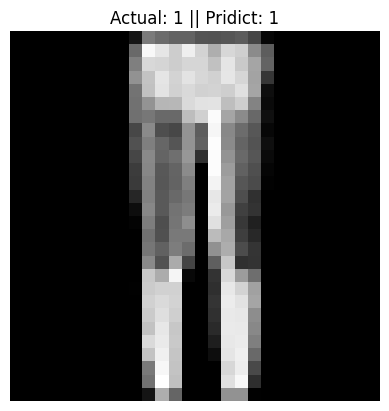

In [27]:
predict_img(3)